In [1]:
# CELL 1: Importation des librairies et chargement du dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chargement du dataset
df = pd.read_csv('data/raw/weatherAUS.csv')

# Verification rapide
print("Dataset charge avec succes!")
print(f"\nDimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nPremières 5 lignes:")
df.head()

Dataset charge avec succes!

Dimensions: 145,460 lignes × 23 colonnes

Colonnes: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

Premières 5 lignes:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [2]:
# CELL 2.A: Informations de base sur le dataset et valeurs manquantes

print("="*60)
print("INFORMATIONS GÉNÉRALES")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("ANALYSE DES VALEURS MANQUANTES")
print("="*60)

# Calcul des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df)) * 100
})

# Trier par pourcentage décroissant
missing_data = missing_data[missing_data['Nombre_Missing'] > 0].sort_values(
    'Pourcentage_Missing', ascending=False
)

print("\nVariables avec valeurs manquantes:")
print(missing_data.to_string(index=False))

print(f"\nLignes avec au moins une valeur manquante: {df.isnull().any(axis=1).sum():,} ({df.isnull().any(axis=1).sum()/len(df)*100:.1f}%)")

INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89

             MinTemp        MaxTemp       Rainfall   Evaporation  \
count  143975.000000  144199.000000  142199.000000  82670.000000   
mean       12.194034      23.221348       2.360918      5.468232   
std         6.398495       7.119049       8.478060      4.193704   
min        -8.500000      -4.800000       0.000000      0.000000   
25%         7.600000      17.900000       0.000000      2.600000   
50%        12.000000      22.600000       0.000000      4.800000   
75%        16.900000      28.200000       0.800000      7.400000   
max        33.900000      48.100000     371.000000    145.000000   

           Sunshine  WindGustSpeed   WindSpeed9am   WindSpeed3pm  \
count  75625.000000  135197.000000  143693.000000  142398.000000   
mean       7.611178      40.035230      14.043426      18.662657   
std        3.785483      13.607062       8.915375       8.809800   
min        0.000000       6.000000       0.000000       0.000000   
25%        4.800000      31.000000       7.0000


Lignes avec au moins une valeur manquante: 89,040 (61.2%)


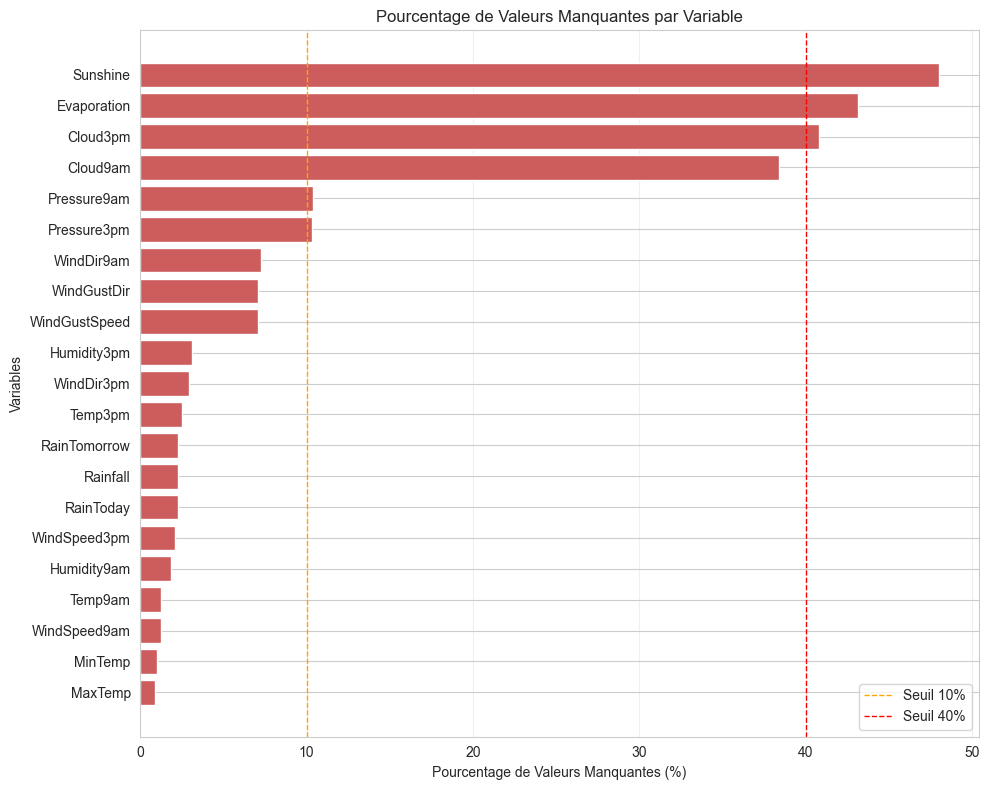

In [3]:
# CELL 2.B: Visualisation des valeurs manquantes

# Calcul des pourcentages de valeurs manquantes
missing_data = pd.DataFrame({
    'Variable': df.columns,
    'Pourcentage_Missing': (df.isnull().sum() / len(df)) * 100
})

# Garder seulement les variables avec des valeurs manquantes
missing_data = missing_data[missing_data['Pourcentage_Missing'] > 0].sort_values(
    'Pourcentage_Missing', ascending=True
)

# Graphique en barres horizontales
plt.figure(figsize=(10, 8))
plt.barh(missing_data['Variable'], missing_data['Pourcentage_Missing'], color='indianred')
plt.xlabel('Pourcentage de Valeurs Manquantes (%)')
plt.ylabel('Variables')
plt.title('Pourcentage de Valeurs Manquantes par Variable')
plt.axvline(x=10, color='orange', linestyle='--', linewidth=1, label='Seuil 10%')
plt.axvline(x=40, color='red', linestyle='--', linewidth=1, label='Seuil 40%')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

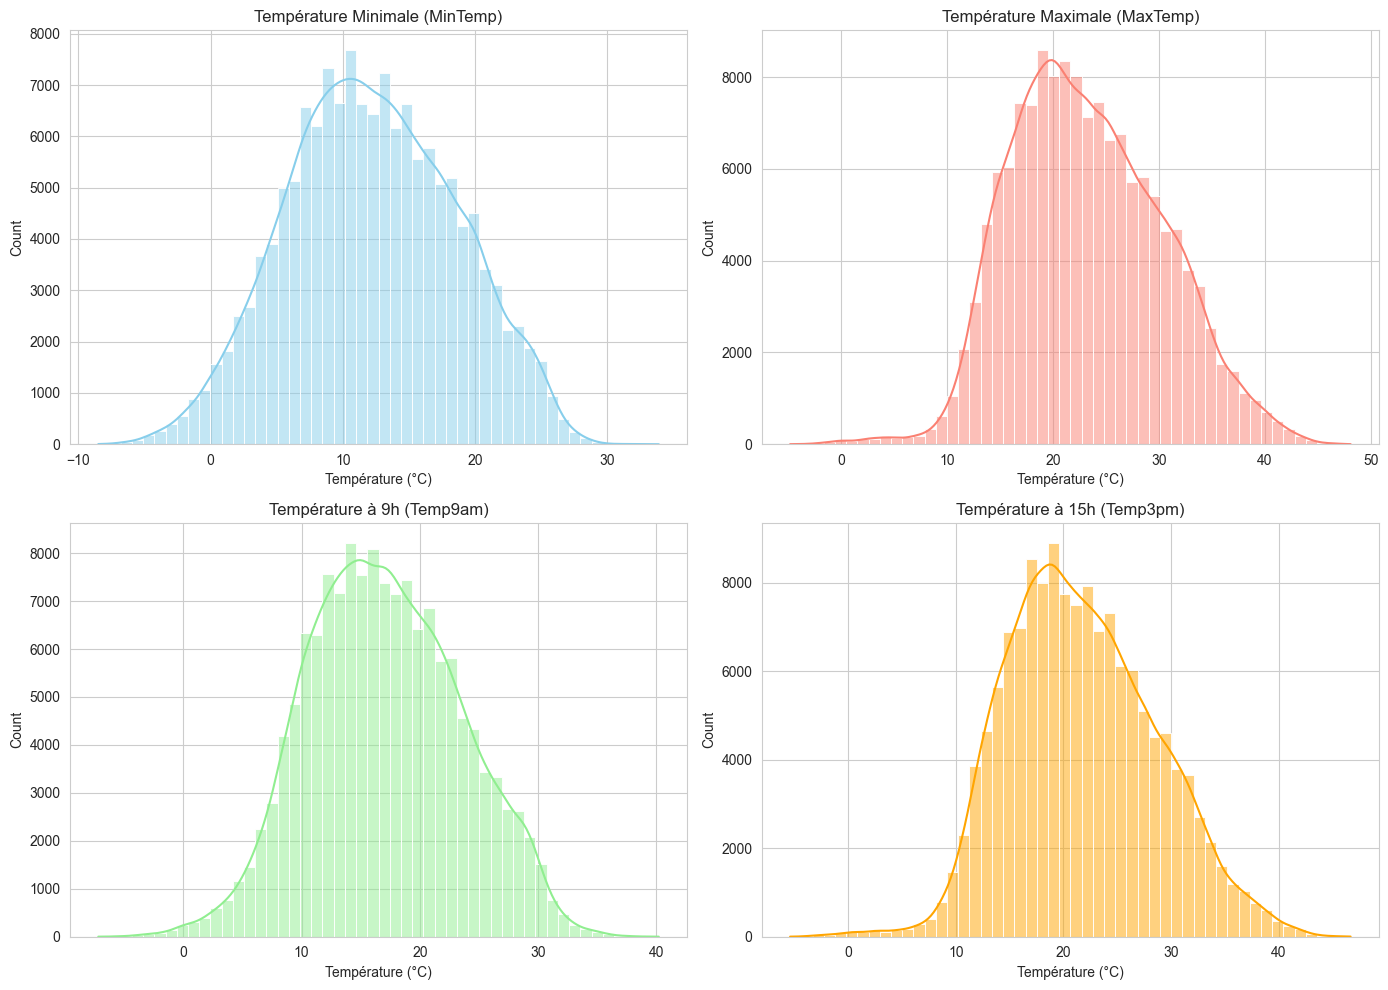

In [4]:
# CELL 3.A: Distribution des températures

plt.figure(figsize=(14, 10))

plt.subplot(221)
sns.histplot(df['MinTemp'], bins=50, color='skyblue', kde=True)
plt.title('Température Minimale (MinTemp)')
plt.xlabel('Température (°C)')

plt.subplot(222)
sns.histplot(df['MaxTemp'], bins=50, color='salmon', kde=True)
plt.title('Température Maximale (MaxTemp)')
plt.xlabel('Température (°C)')

plt.subplot(223)
sns.histplot(df['Temp9am'], bins=50, color='lightgreen', kde=True)
plt.title('Température à 9h (Temp9am)')
plt.xlabel('Température (°C)')

plt.subplot(224)
sns.histplot(df['Temp3pm'], bins=50, color='orange', kde=True)
plt.title('Température à 15h (Temp3pm)')
plt.xlabel('Température (°C)')

plt.tight_layout()
plt.show()

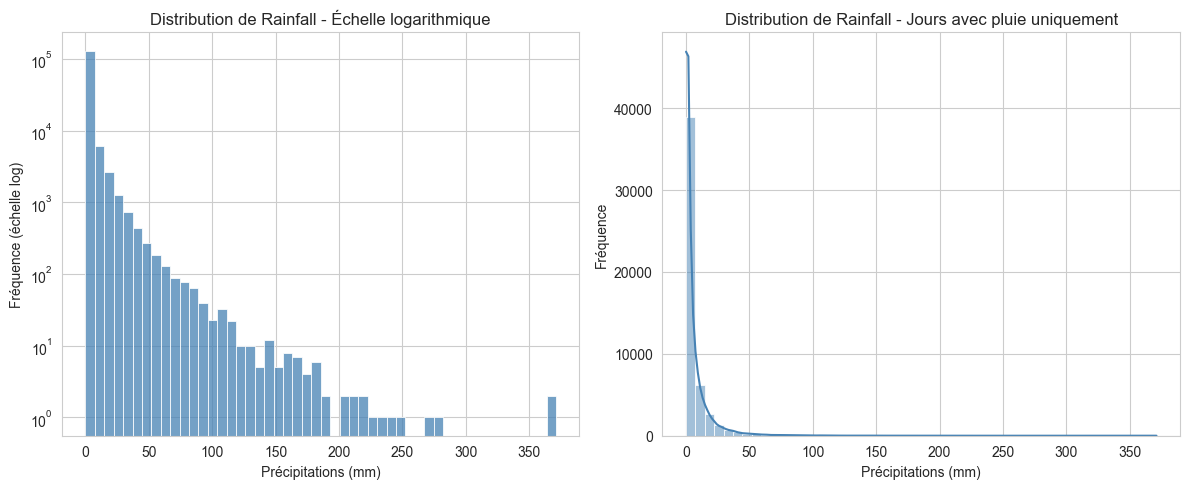

In [5]:
# CELL 3.B: Distribution de Rainfall (échelle logarithmique)

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Rainfall'], bins=50, color='steelblue', kde=False)
plt.yscale('log')
plt.title('Distribution de Rainfall - Échelle logarithmique')
plt.xlabel('Précipitations (mm)')
plt.ylabel('Fréquence (échelle log)')

plt.subplot(122)
sns.histplot(df['Rainfall'][df['Rainfall'] > 0], bins=50, color='steelblue', kde=True)
plt.title('Distribution de Rainfall - Jours avec pluie uniquement')
plt.xlabel('Précipitations (mm)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

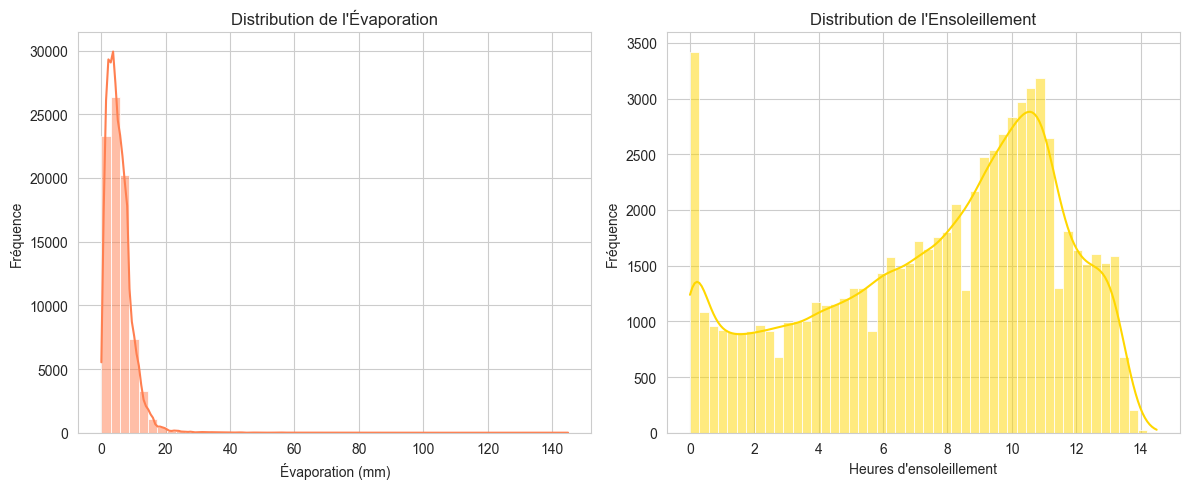

In [6]:
# CELL 3.C: Distribution de l'évaporation et de l'ensoleillement

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Evaporation'], bins=50, color='coral', kde=True)
plt.title('Distribution de l\'Évaporation')
plt.xlabel('Évaporation (mm)')
plt.ylabel('Fréquence')

plt.subplot(122)
sns.histplot(df['Sunshine'], bins=50, color='gold', kde=True)
plt.title('Distribution de l\'Ensoleillement')
plt.xlabel('Heures d\'ensoleillement')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

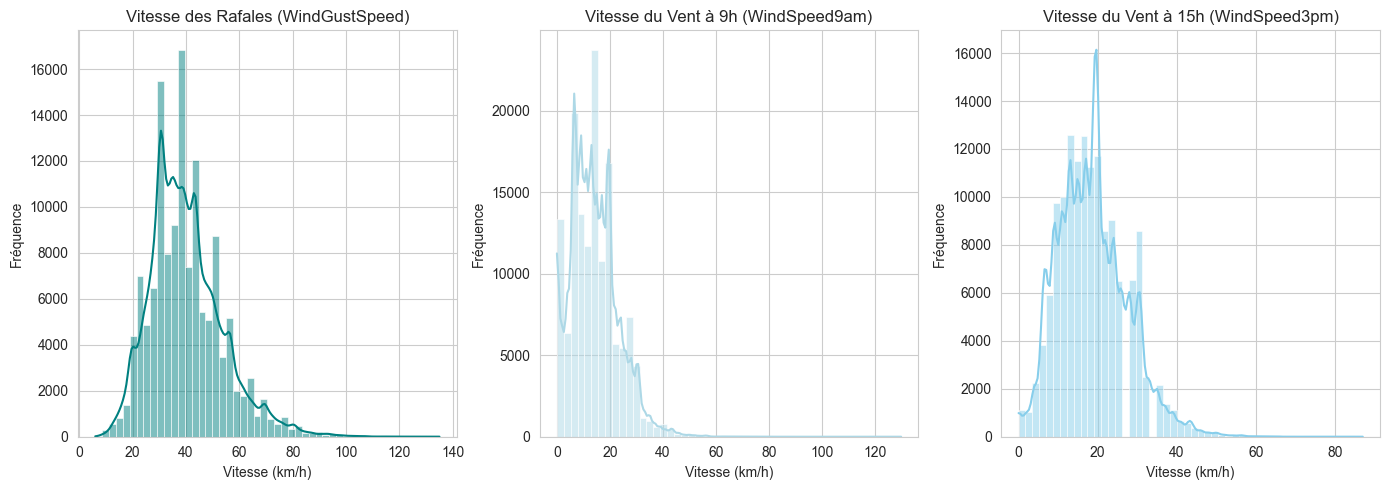

In [7]:
# CELL 3.D: Distribution des variables de vent

plt.figure(figsize=(14, 5))

plt.subplot(131)
sns.histplot(df['WindGustSpeed'], bins=50, color='teal', kde=True)
plt.title('Vitesse des Rafales (WindGustSpeed)')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Fréquence')

plt.subplot(132)
sns.histplot(df['WindSpeed9am'], bins=50, color='lightblue', kde=True)
plt.title('Vitesse du Vent à 9h (WindSpeed9am)')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Fréquence')

plt.subplot(133)
sns.histplot(df['WindSpeed3pm'], bins=50, color='skyblue', kde=True)
plt.title('Vitesse du Vent à 15h (WindSpeed3pm)')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

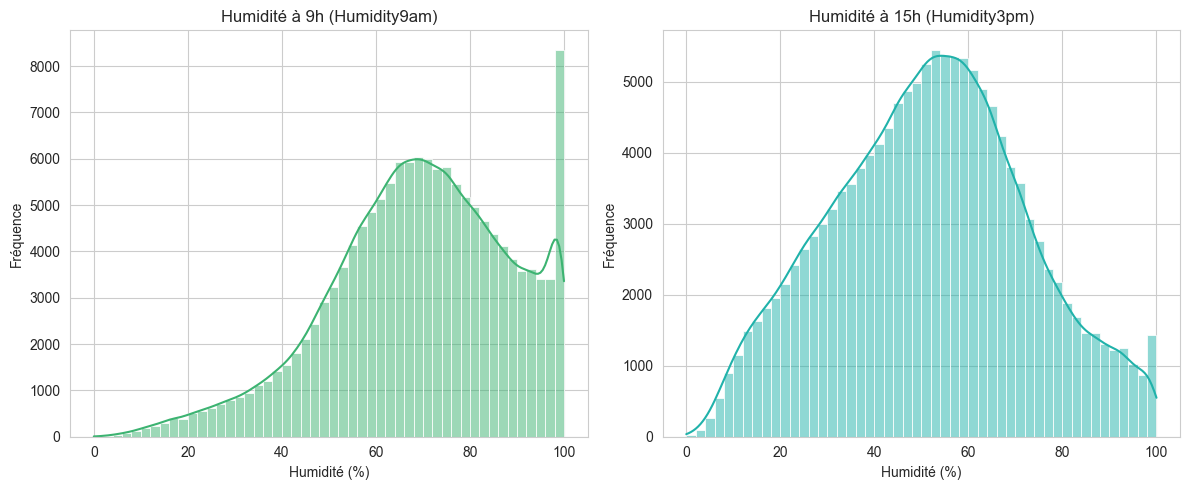

In [8]:
# CELL 3.E: Distribution de l'humidité

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Humidity9am'], bins=50, color='mediumseagreen', kde=True)
plt.title('Humidité à 9h (Humidity9am)')
plt.xlabel('Humidité (%)')
plt.ylabel('Fréquence')

plt.subplot(122)
sns.histplot(df['Humidity3pm'], bins=50, color='lightseagreen', kde=True)
plt.title('Humidité à 15h (Humidity3pm)')
plt.xlabel('Humidité (%)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

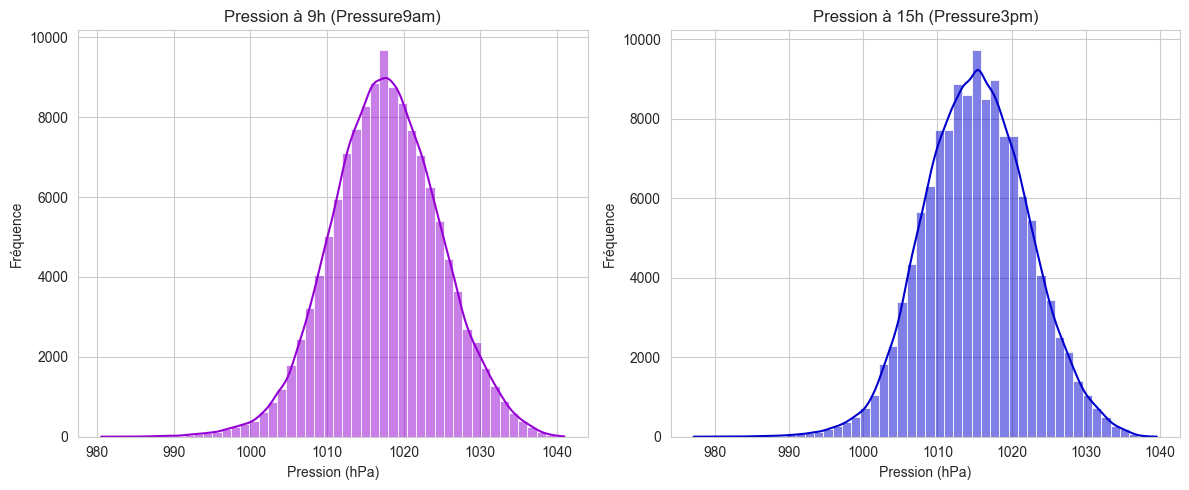

In [9]:
# CELL 3.F: Distribution de la pression atmosphérique

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Pressure9am'], bins=50, color='darkviolet', kde=True)
plt.title('Pression à 9h (Pressure9am)')
plt.xlabel('Pression (hPa)')
plt.ylabel('Fréquence')

plt.subplot(122)
sns.histplot(df['Pressure3pm'], bins=50, color='mediumblue', kde=True)
plt.title('Pression à 15h (Pressure3pm)')
plt.xlabel('Pression (hPa)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

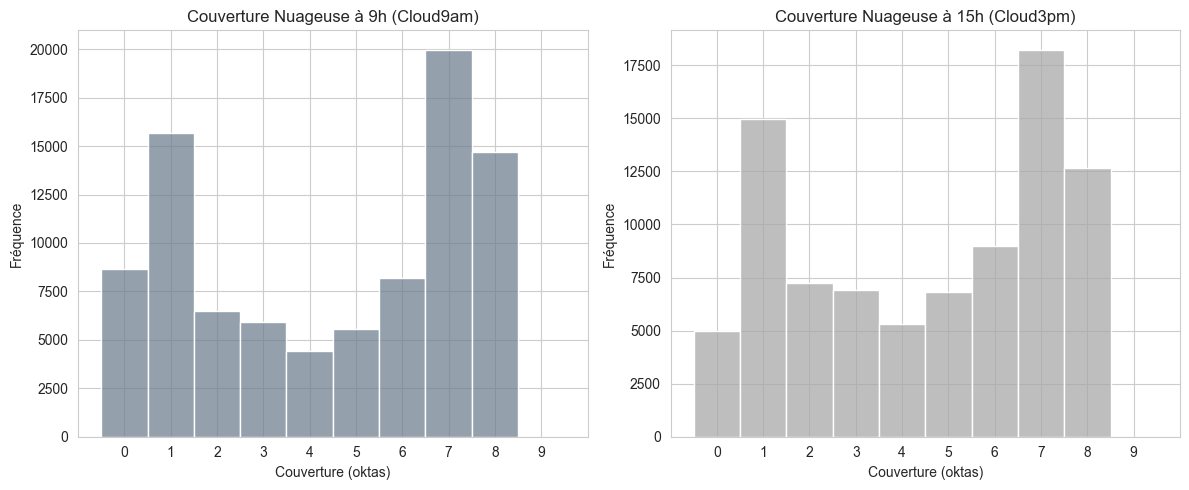

In [10]:
# CELL 3.G: Distribution de la couverture nuageuse

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(df['Cloud9am'], bins=10, color='slategray', kde=False, discrete=True)
plt.title('Couverture Nuageuse à 9h (Cloud9am)')
plt.xlabel('Couverture (oktas)')
plt.ylabel('Fréquence')
plt.xticks(range(0, 10))

plt.subplot(122)
sns.histplot(df['Cloud3pm'], bins=10, color='darkgray', kde=False, discrete=True)
plt.title('Couverture Nuageuse à 15h (Cloud3pm)')
plt.xlabel('Couverture (oktas)')
plt.ylabel('Fréquence')
plt.xticks(range(0, 10))

plt.tight_layout()
plt.show()

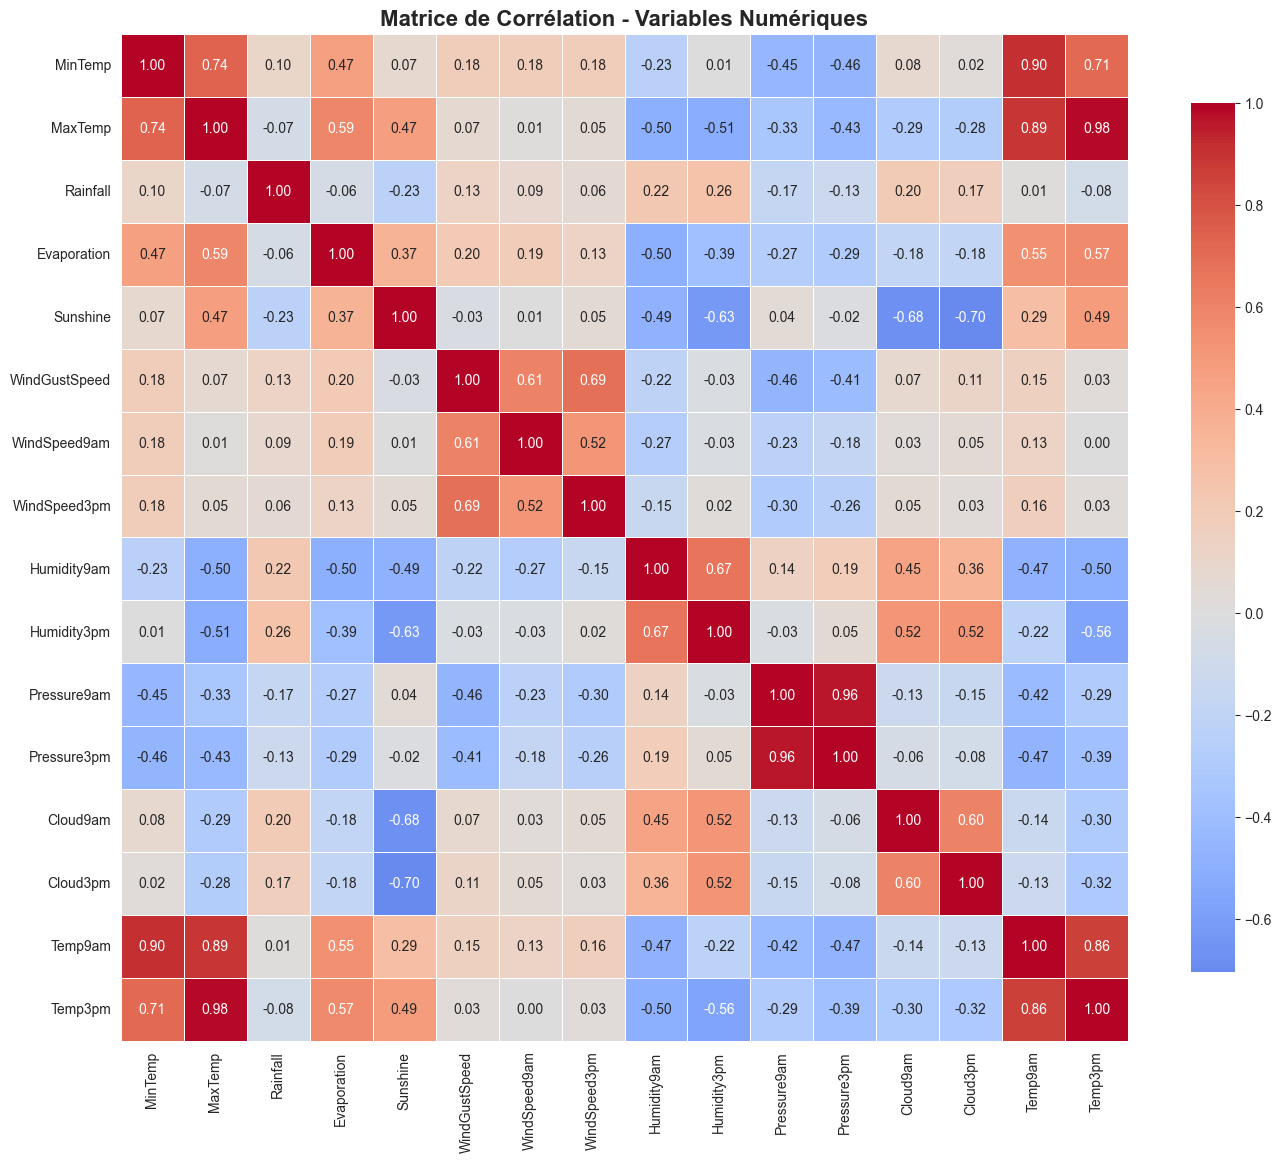

In [11]:
# CELL 4.A: Heatmap de corrélation entre variables numériques

# Sélectionner uniquement les variables numériques
numerical_cols = df.select_dtypes(include=['float64']).columns

# Calculer la matrice de corrélation
correlation_matrix = df[numerical_cols].corr()

# Créer la heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation - Variables Numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

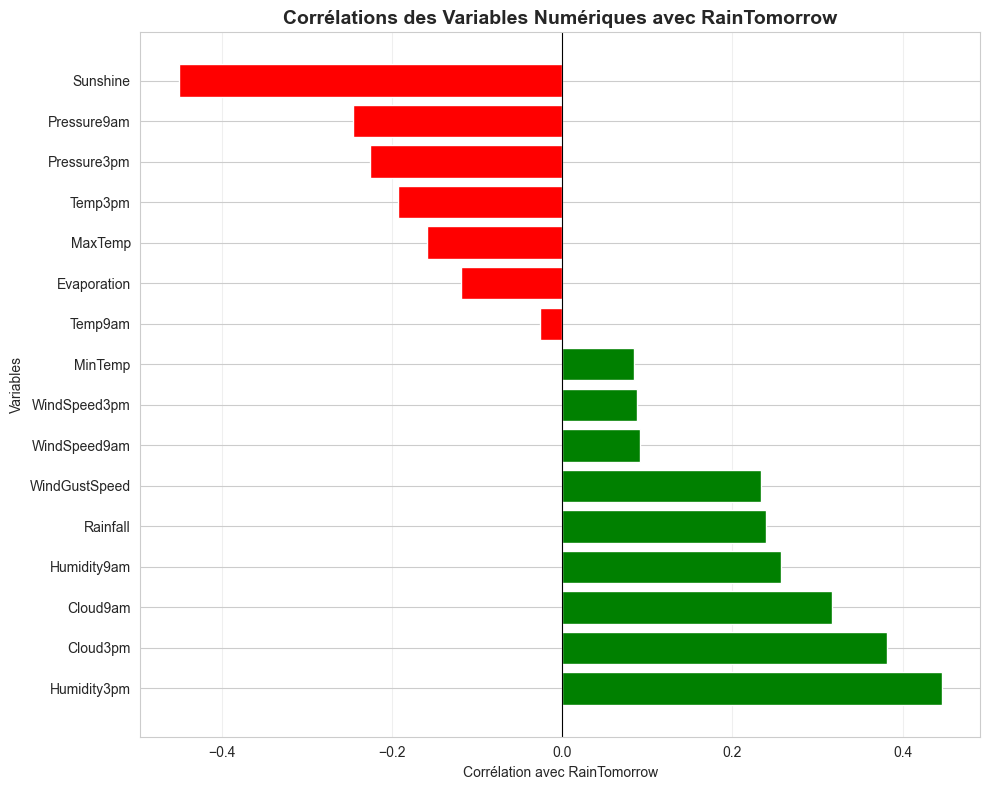

Corrélations avec RainTomorrow (ordre décroissant):
Humidity3pm      0.446160
Cloud3pm         0.381870
Cloud9am         0.317380
Humidity9am      0.257161
Rainfall         0.239032
WindGustSpeed    0.234010
WindSpeed9am     0.090995
WindSpeed3pm     0.087817
MinTemp          0.083936
Temp9am         -0.025691
Evaporation     -0.119285
MaxTemp         -0.159237
Temp3pm         -0.192424
Pressure3pm     -0.226031
Pressure9am     -0.246371
Sunshine        -0.450768
dtype: float64


In [12]:
# CELL 4.B: Analyse des corrélations avec la variable cible

# Convertir RainTomorrow en numérique (Yes=1, No=0)
df['RainTomorrow_numeric'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Calculer les corrélations avec la cible
correlations_target = df[numerical_cols].corrwith(df['RainTomorrow_numeric']).sort_values(ascending=False)

# Créer le graphique
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in correlations_target.values]
plt.barh(correlations_target.index, correlations_target.values, color=colors)
plt.xlabel('Corrélation avec RainTomorrow')
plt.ylabel('Variables')
plt.title('Corrélations des Variables Numériques avec RainTomorrow', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Corrélations avec RainTomorrow (ordre décroissant):")
print(correlations_target)

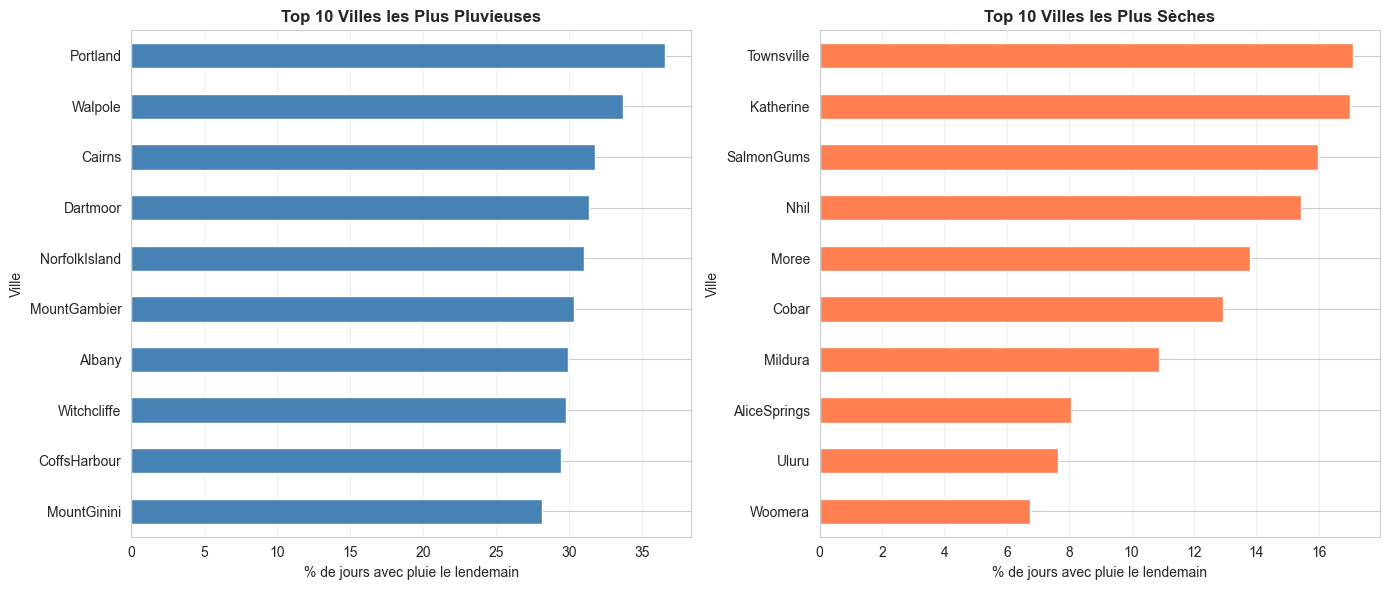

In [13]:
# CELL 4.C: Analyse géographique - Fréquence de pluie par ville

# Calculer le pourcentage de jours avec pluie par location
location_rain = df.groupby('Location')['RainTomorrow_numeric'].mean() * 100

# Top 10 villes les plus pluvieuses
top_10_rainy = location_rain.sort_values(ascending=False).head(10)

# Top 10 villes les plus sèches
top_10_dry = location_rain.sort_values(ascending=True).head(10)

# Créer le graphique
plt.figure(figsize=(14, 6))

plt.subplot(121)
top_10_rainy.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Villes les Plus Pluvieuses', fontsize=12, fontweight='bold')
plt.xlabel('% de jours avec pluie le lendemain')
plt.ylabel('Ville')
plt.grid(axis='x', alpha=0.3)

plt.subplot(122)
top_10_dry.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Villes les Plus Sèches', fontsize=12, fontweight='bold')
plt.xlabel('% de jours avec pluie le lendemain')
plt.ylabel('Ville')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

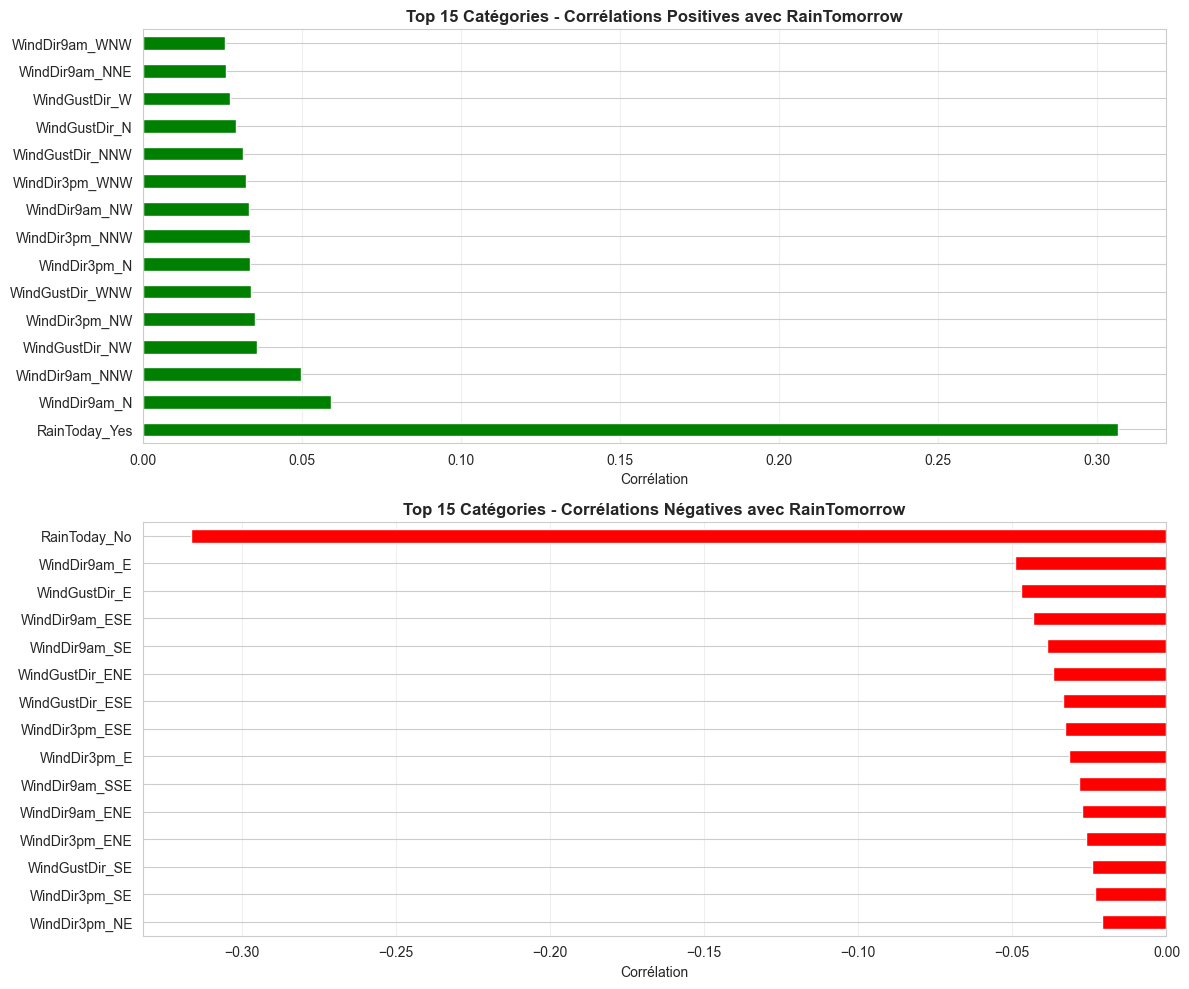

In [14]:
# CELL 4.D: Corrélations des variables catégorielles avec RainTomorrow

# Encoder les variables catégorielles
categorical_vars = ['RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

# One-hot encoding
df_encoded = pd.get_dummies(df[categorical_vars], drop_first=False)

# Ajouter la variable cible numérique
df_encoded['RainTomorrow_numeric'] = df['RainTomorrow_numeric']

# Calculer les corrélations avec la cible
cat_correlations = df_encoded.drop('RainTomorrow_numeric', axis=1).corrwith(df_encoded['RainTomorrow_numeric']).sort_values(ascending=False)

# Afficher top 15 corrélations positives et négatives
top_15 = cat_correlations.head(15)
bottom_15 = cat_correlations.tail(15)

plt.figure(figsize=(12, 10))

plt.subplot(211)
top_15.plot(kind='barh', color='green')
plt.title('Top 15 Catégories - Corrélations Positives avec RainTomorrow', fontsize=12, fontweight='bold')
plt.xlabel('Corrélation')
plt.grid(axis='x', alpha=0.3)

plt.subplot(212)
bottom_15.plot(kind='barh', color='red')
plt.title('Top 15 Catégories - Corrélations Négatives avec RainTomorrow', fontsize=12, fontweight='bold')
plt.xlabel('Corrélation')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# CELL 5: Test d'independance Chi-2 et V de Cramer (variables categorielles vs cible)

from scipy.stats import chi2_contingency

# Rechargement pour garantir le dataset brut complet
df = pd.read_csv('data/raw/weatherAUS.csv')

# Variables categorielles a tester contre la cible RainTomorrow
variables_cat = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

def interpreter_cramer(v):
    # Seuils de la formation
    if v >= 0.8:
        return 'Multicolinearite suspectee'
    elif v >= 0.5:
        return 'Elevee'
    elif v >= 0.3:
        return 'Moyenne'
    else:
        return 'Faible'

resultats = []
for var in variables_cat:
    crosstab = pd.crosstab(df[var], df['RainTomorrow'])
    stat, p, dof, expected = chi2_contingency(crosstab)
    N = crosstab.values.sum()  # nombre d'observations non manquantes utilisees pour ce test
    # Cette forme de V de Cramer est exacte ici car la cible est binaire (min(r-1, k-1) = 1)
    V_Cramer = np.sqrt(stat / N)
    resultats.append({
        'Variable': var,
        'N': N,
        'Chi2': stat,
        'dof': dof,
        'p_valeur': p,
        'V_Cramer': V_Cramer,
        'Interpretation': interpreter_cramer(V_Cramer)
    })

resultats_cat = pd.DataFrame(resultats).sort_values('V_Cramer', ascending=False).reset_index(drop=True)

# Mise en forme pour l'affichage
resultats_affichage = resultats_cat.copy()
resultats_affichage['Chi2'] = resultats_affichage['Chi2'].round(2)
resultats_affichage['p_valeur'] = resultats_affichage['p_valeur'].apply(lambda x: f"{x:.2e}")
resultats_affichage['V_Cramer'] = resultats_affichage['V_Cramer'].round(4)

print("Test d'independance Chi-2 et V de Cramer (variables categorielles vs RainTomorrow):")
print(resultats_affichage.to_string(index=False))

Test d'independance Chi-2 et V de Cramer (variables categorielles vs RainTomorrow):
   Variable      N     Chi2  dof  p_valeur  V_Cramer Interpretation
  RainToday 140787 13799.48    1  0.00e+00    0.3131        Moyenne
   Location 142193  3544.79   48  0.00e+00    0.1579         Faible
 WindDir9am 132180  2214.85   15  0.00e+00    0.1294         Faible
WindGustDir 132863  1519.90   15  0.00e+00    0.1070         Faible
 WindDir3pm 138415  1281.27   15 5.65e-264    0.0962         Faible


Figure sauvegardee: figures/etape1_cramer_v_categorielles.png


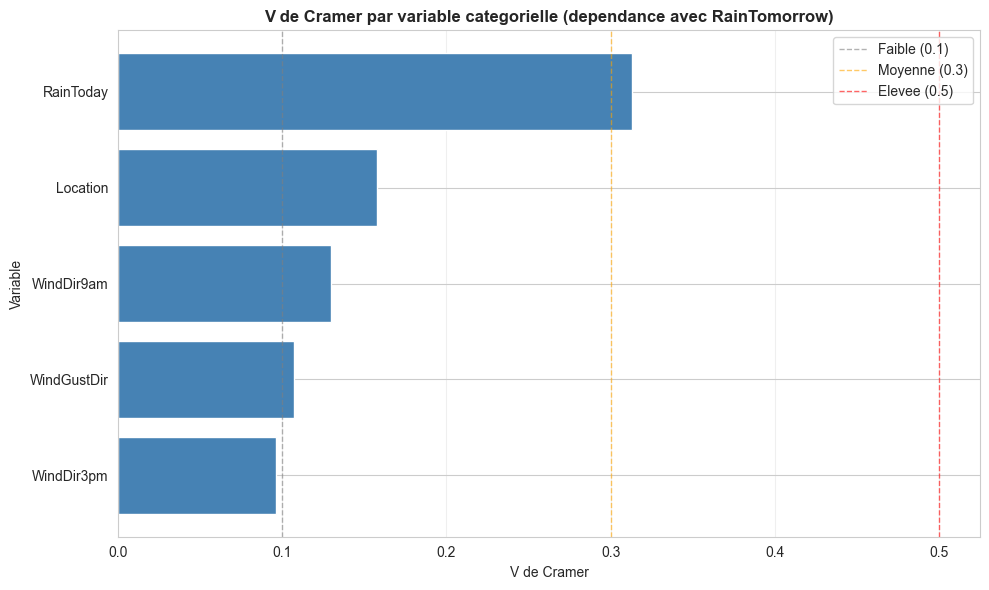

In [16]:
# CELL 6: Graphique V de Cramer par variable categorielle

data_plot = resultats_cat.sort_values('V_Cramer', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(data_plot['Variable'], data_plot['V_Cramer'], color='steelblue')
plt.axvline(x=0.1, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Faible (0.1)')
plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Moyenne (0.3)')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Elevee (0.5)')
plt.title('V de Cramer par variable categorielle (dependance avec RainTomorrow)', fontsize=12, fontweight='bold')
plt.xlabel('V de Cramer')
plt.ylabel('Variable')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/etape1_cramer_v_categorielles.png', dpi=100, bbox_inches='tight')
print("Figure sauvegardee: figures/etape1_cramer_v_categorielles.png")
plt.show()

Figure sauvegardee: figures/etape1_taux_pluie_par_categorie.png


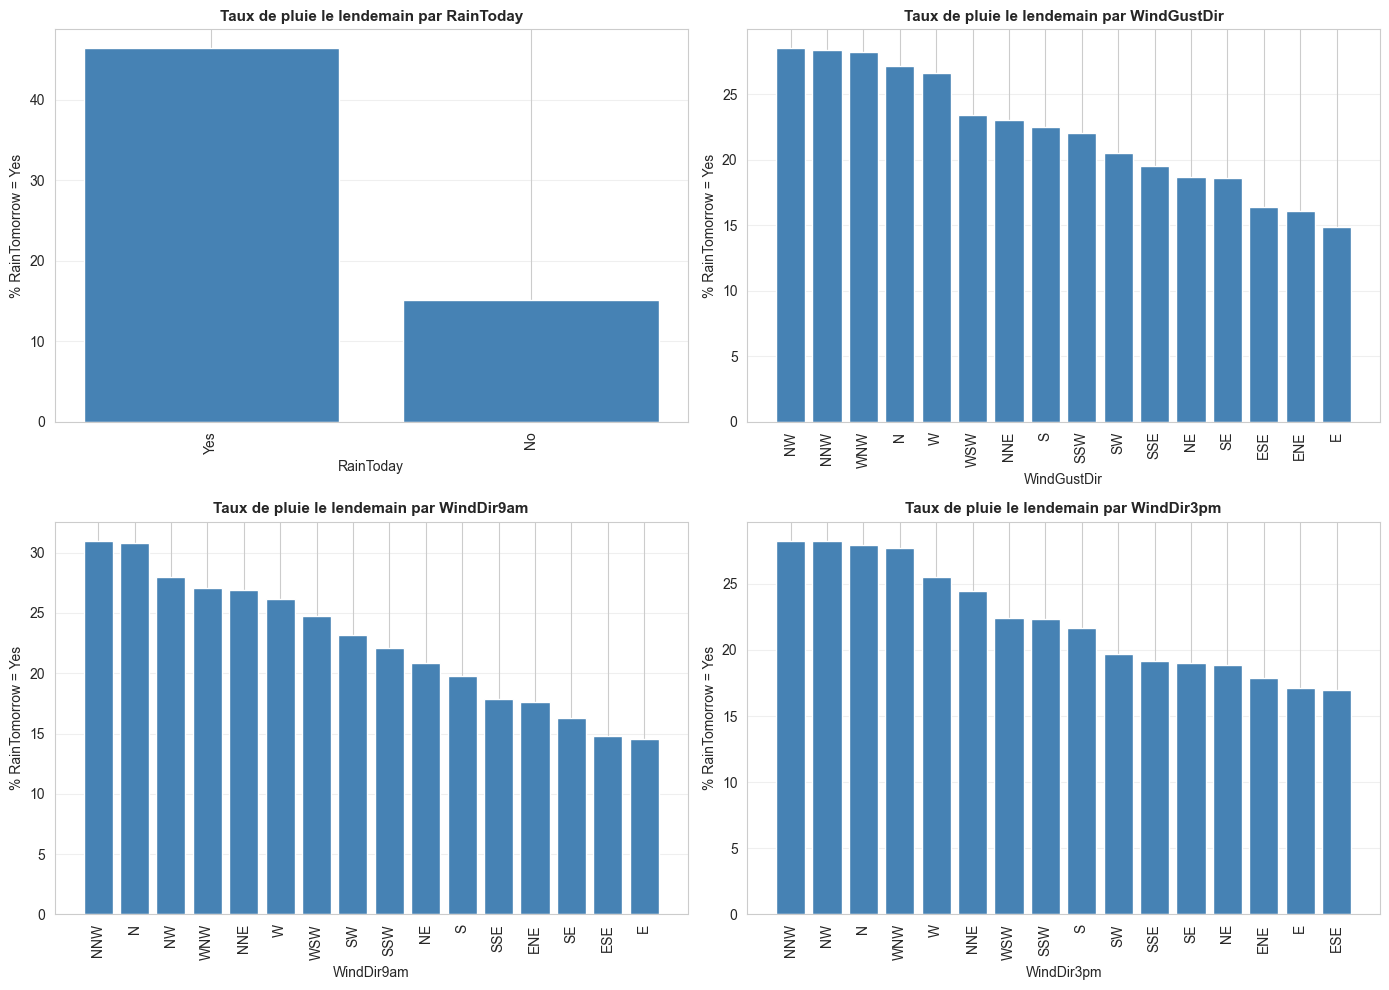

In [17]:
# CELL 7: Taux de pluie le lendemain par categorie (visualisation de la dependance)

# Cible binaire numerique : Yes = 1, No = 0, NaN conserve pour etre exclu des moyennes
cible_num = (df['RainTomorrow'] == 'Yes').astype(float)
cible_num[df['RainTomorrow'].isnull()] = np.nan
df_taux = df.assign(cible_pluie=cible_num)

variables_grille = ['RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, var in enumerate(variables_grille):
    # Proportion de RainTomorrow = Yes dans chaque categorie (en pourcentage)
    taux = df_taux.groupby(var)['cible_pluie'].mean() * 100
    taux = taux.sort_values(ascending=False)
    axes[i].bar(taux.index.astype(str), taux.values, color='steelblue')
    axes[i].set_title(f"Taux de pluie le lendemain par {var}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('% RainTomorrow = Yes')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/etape1_taux_pluie_par_categorie.png', dpi=100, bbox_inches='tight')
print("Figure sauvegardee: figures/etape1_taux_pluie_par_categorie.png")
plt.show()

Figure sauvegardee: figures/etape1_boxplots_numeriques_vs_cible.png


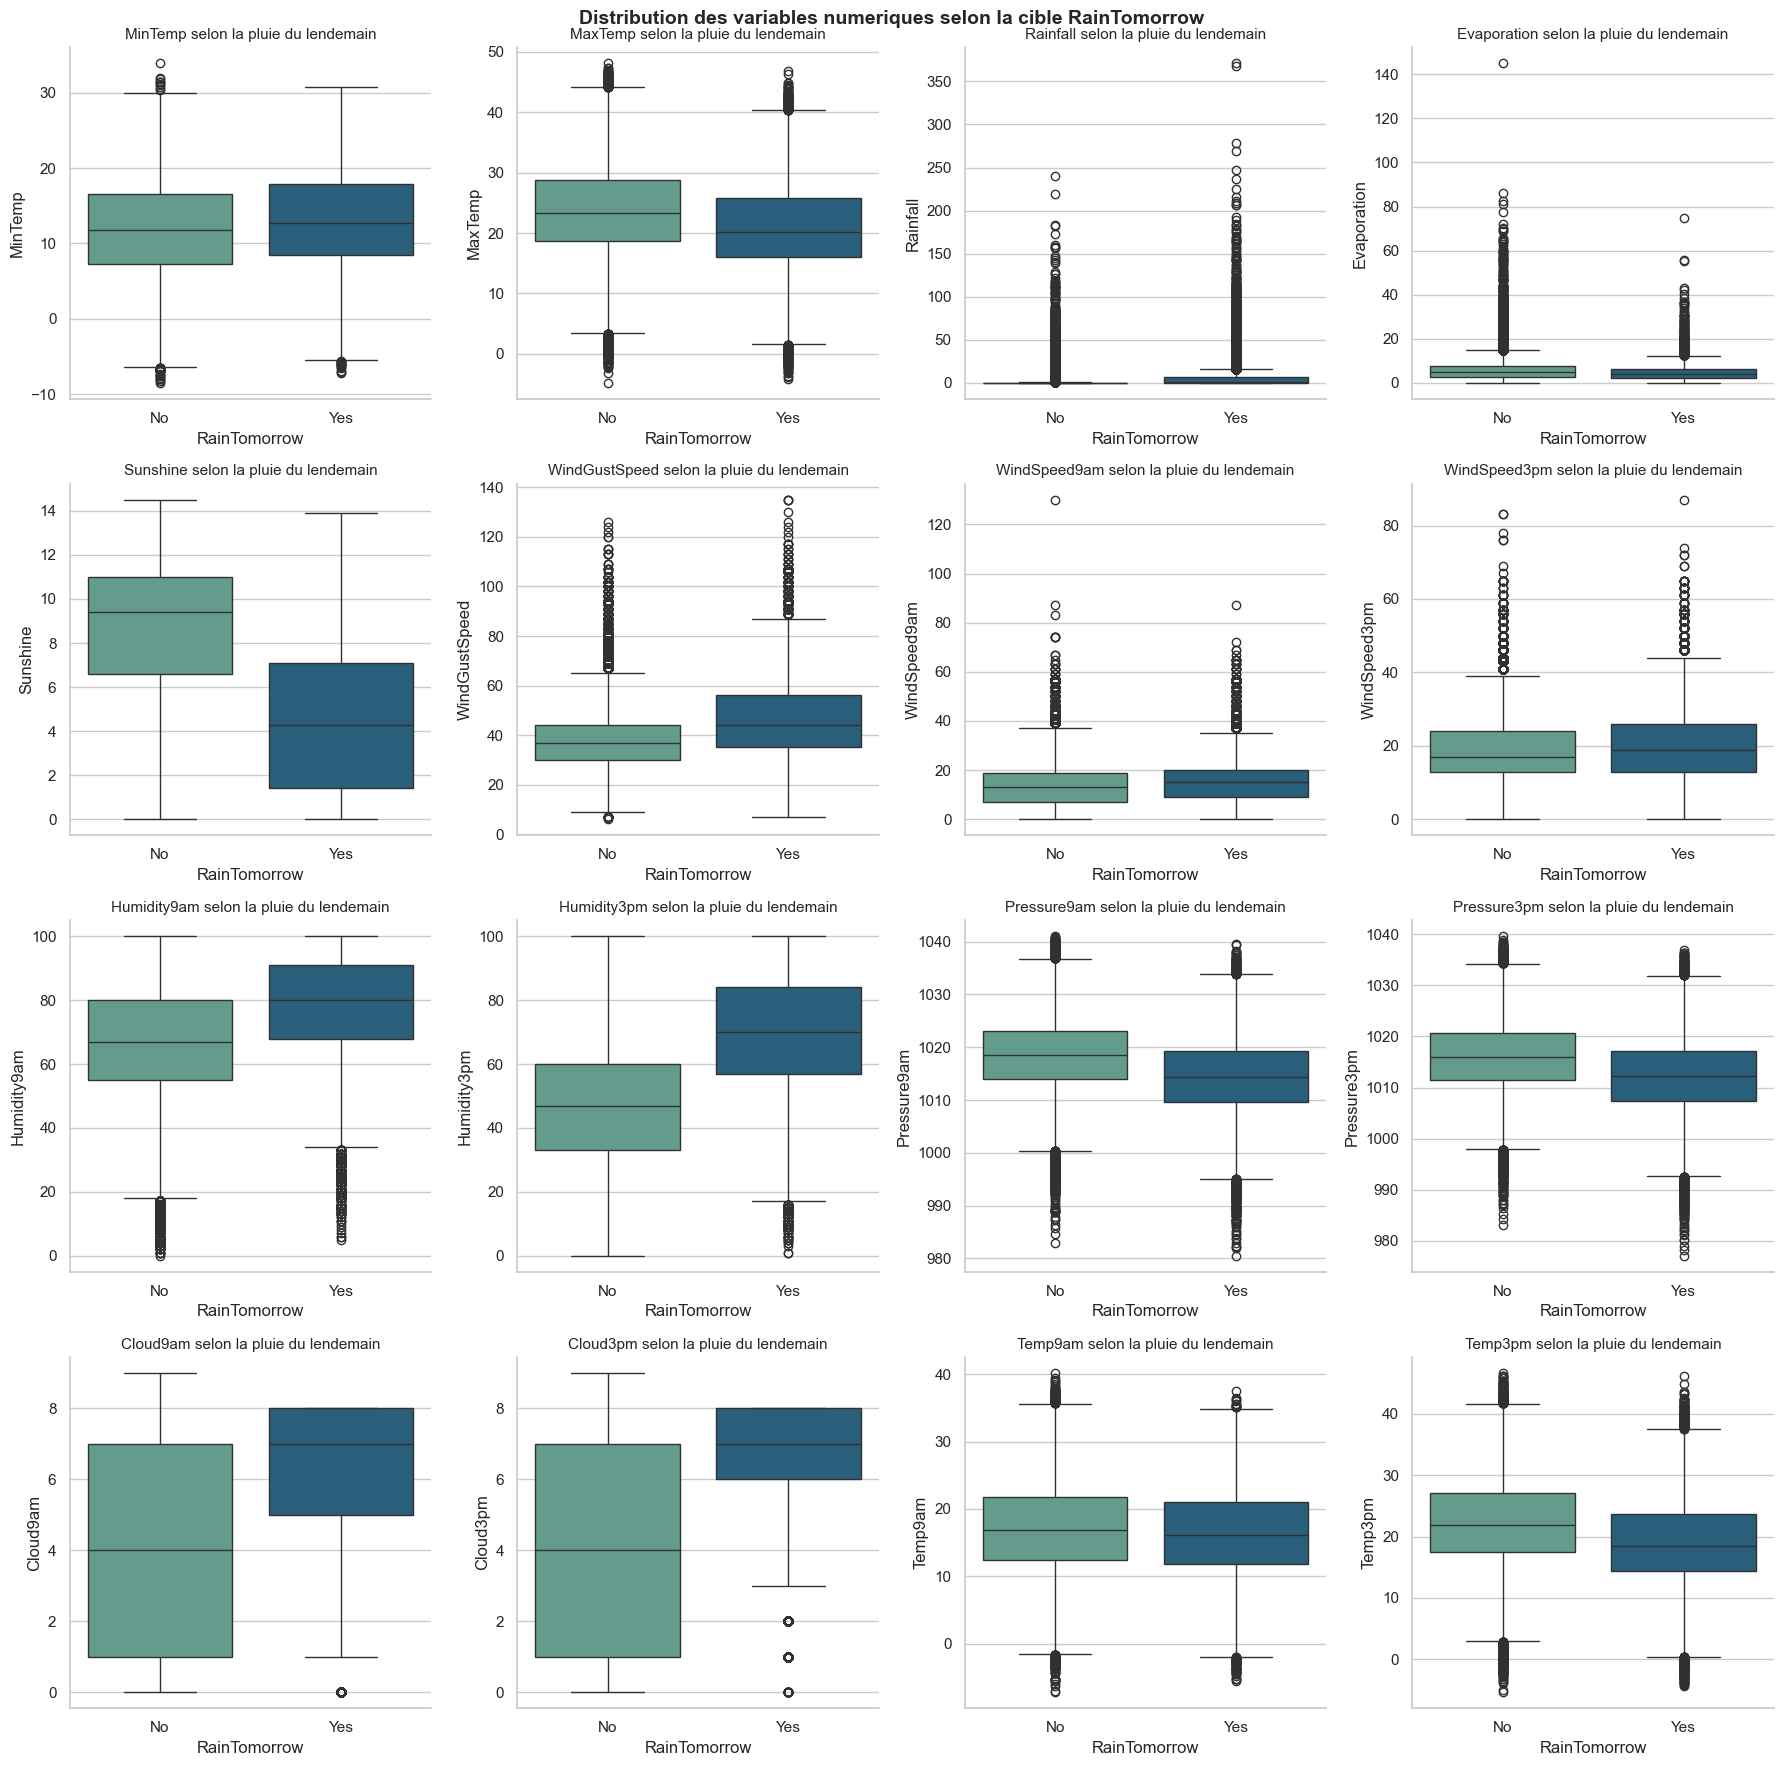

In [18]:
# CELL 8: Boxplots des variables numeriques selon la cible (RainTomorrow)

import seaborn as sns

# Rechargement pour garantir le dataset brut complet
df = pd.read_csv('data/raw/weatherAUS.csv')

# EDA avant preprocessing : on inclut TOUTES les variables numeriques (16),
# y compris les quatre a forte proportion de valeurs manquantes (Evaporation, Sunshine, Cloud9am, Cloud3pm)
variables_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

# On conserve uniquement les lignes ou la cible vaut 'No' ou 'Yes' (exclusion des NaN)
df_box = df[df['RainTomorrow'].isin(['No', 'Yes'])]

# Style
sns.set_theme(style="whitegrid", context="notebook")
palette = {"No": sns.color_palette("crest")[1], "Yes": sns.color_palette("crest")[4]}

# Grille 4x4 : une variable par sous-graphique, outliers conserves
fig, axes = plt.subplots(4, 4, figsize=(18, 18))
axes = axes.ravel()

for i, var in enumerate(variables_num):
    sns.boxplot(x='RainTomorrow', y=var, data=df_box, palette=palette,
                order=['No', 'Yes'], ax=axes[i])
    axes[i].set_title(f"{var} selon la pluie du lendemain", fontsize=11)
    axes[i].set_xlabel('RainTomorrow')
    axes[i].set_ylabel(var)

fig.suptitle("Distribution des variables numeriques selon la cible RainTomorrow",
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
fig.savefig('figures/etape1_boxplots_numeriques_vs_cible.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape1_boxplots_numeriques_vs_cible.png")
plt.show()